In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Load data from the input file insurance.csv
df = pd.read_csv('data/insurance.csv')

In [7]:
# 1.1 Analyze the data
# -------------------------------

print(df.shape) 
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum()) 

(1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000  1338

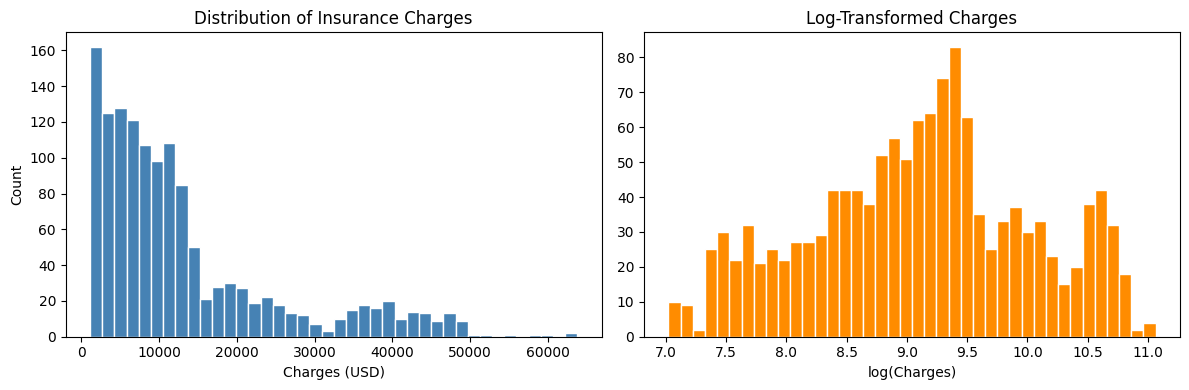

In [8]:
# 1.2. Target variable distribution
# --------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw charges
axes[0].hist(df['charges'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Insurance Charges')
axes[0].set_xlabel('Charges (USD)')
axes[0].set_ylabel('Count')

# Log-transformed charges
axes[1].hist(np.log(df['charges']), bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Log-Transformed Charges')
axes[1].set_xlabel('log(Charges)')

plt.tight_layout()
plt.show()

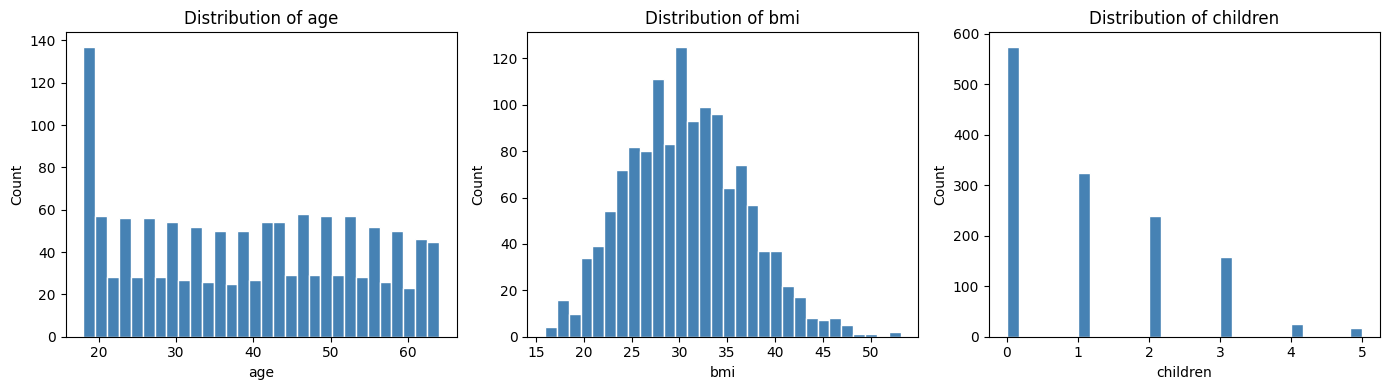

In [16]:
# 1.3. Numeric feature distributions
# -----------------------------------

num_features = ['age', 'bmi', 'children']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

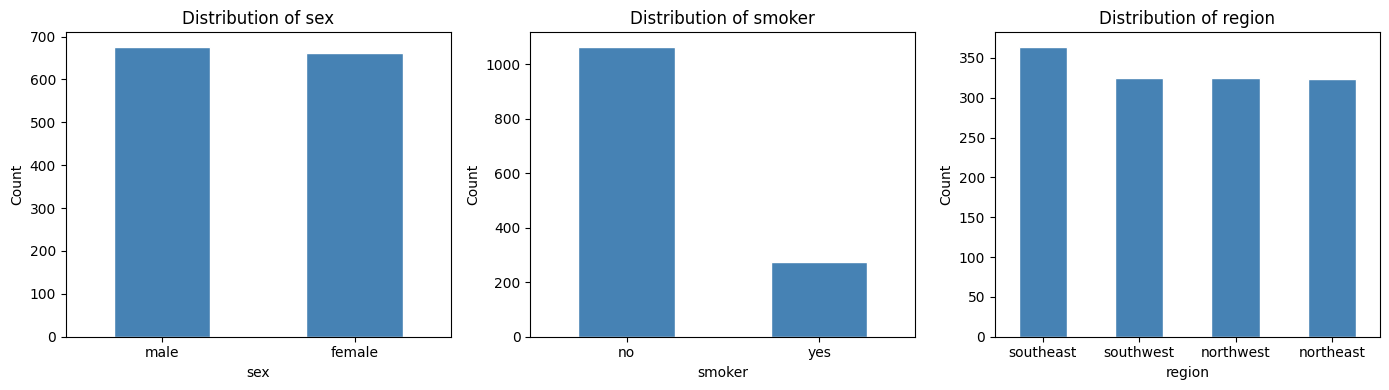

In [18]:
# 1.4. Categorical Feature Distribution
# -----------------------------------------

cat_features = ['sex', 'smoker', 'region']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, col in enumerate(cat_features):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

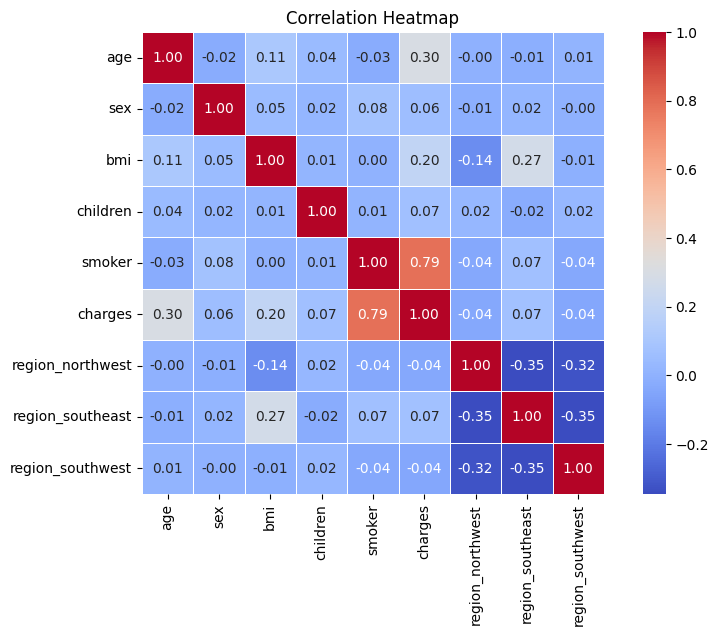

In [19]:
# 1.5. Correlation Heatmap
# -------------------------------

# Temporary encoding just for correlation
df_encoded = df.copy()
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})
df_encoded['sex'] = df_encoded['sex'].map({'male': 1, 'female': 0})
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)

plt.figure(figsize=(10, 6))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.show()

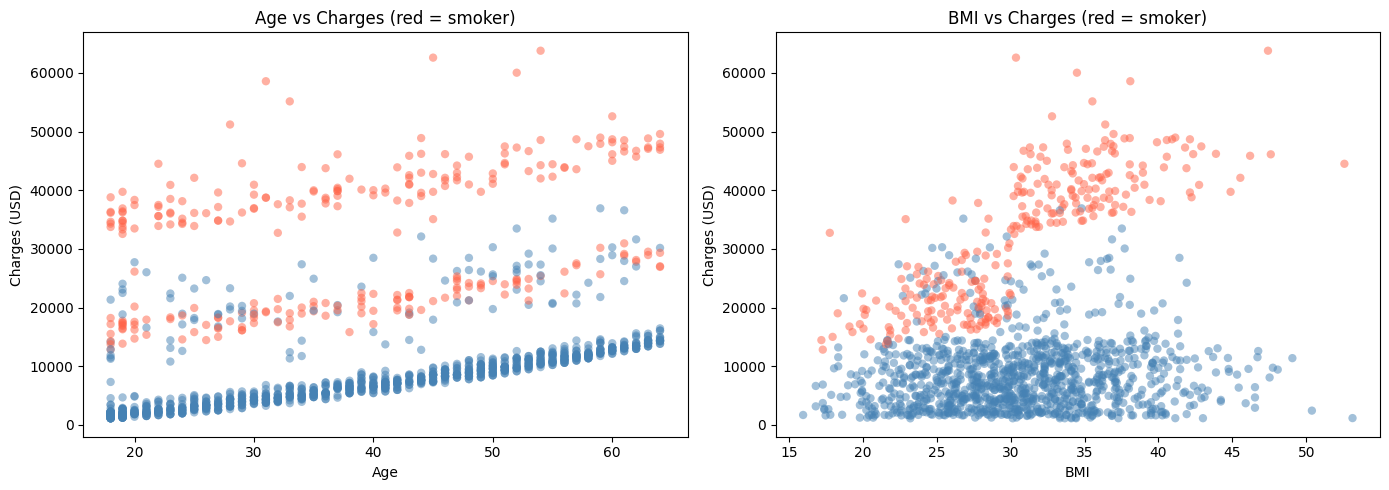

In [20]:
# 1.6. Scatter Plots
# ---------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = df['smoker'].map({'yes': 'tomato', 'no': 'steelblue'})

# Age vs Charges
axes[0].scatter(df['age'], df['charges'], c=colors, alpha=0.5, edgecolors='none')
axes[0].set_title('Age vs Charges (red = smoker)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Charges (USD)')

# BMI vs Charges
axes[1].scatter(df['bmi'], df['charges'], c=colors, alpha=0.5, edgecolors='none')
axes[1].set_title('BMI vs Charges (red = smoker)')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Charges (USD)')

plt.tight_layout()
plt.show()

/var/folders/rc/4bx33ylj3wx1hrd1scs3m9480000gn/T/ipykernel_42700/3691561055.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges', ax=axes[0], palette=['steelblue', 'tomato'])
/var/folders/rc/4bx33ylj3wx1hrd1scs3m9480000gn/T/ipykernel_42700/3691561055.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='charges', ax=axes[1], palette='Blues')
/var/folders/rc/4bx33ylj3wx1hrd1scs3m9480000gn/T/ipykernel_42700/3691561055.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sex', y=

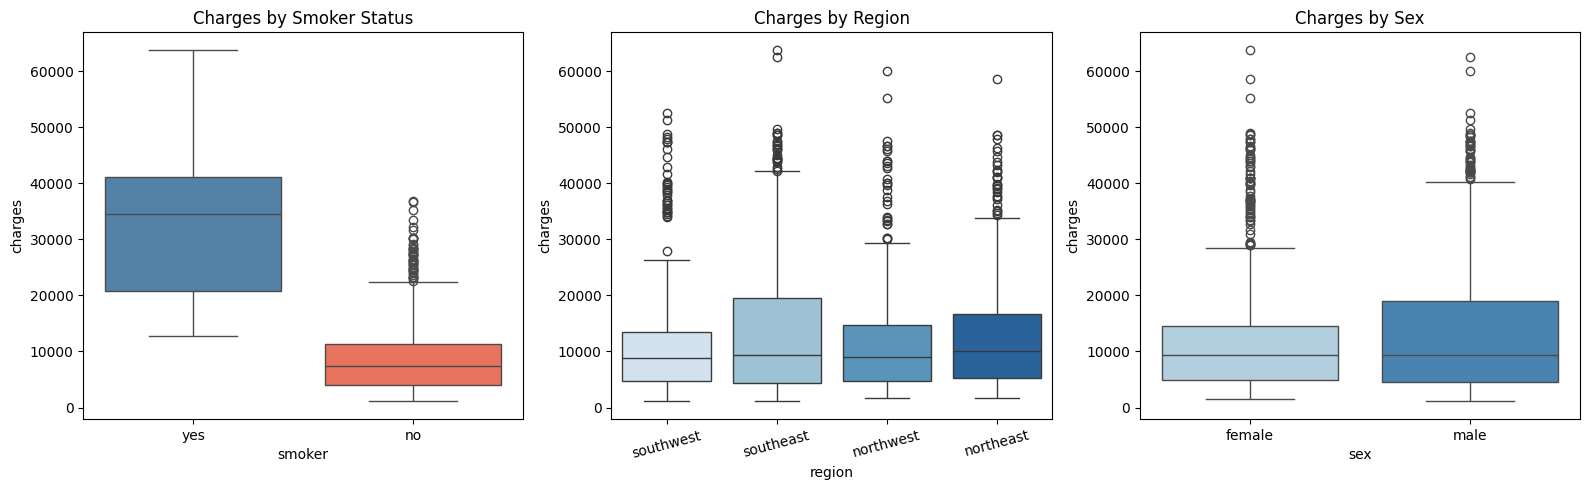

In [21]:
# 1.7. Boxplots by Categorical Features
# ----------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x='smoker', y='charges', ax=axes[0], palette=['steelblue', 'tomato'])
axes[0].set_title('Charges by Smoker Status')

sns.boxplot(data=df, x='region', y='charges', ax=axes[1], palette='Blues')
axes[1].set_title('Charges by Region')
axes[1].tick_params(axis='x', rotation=15)

sns.boxplot(data=df, x='sex', y='charges', ax=axes[2], palette='Blues')
axes[2].set_title('Charges by Sex')

plt.tight_layout()
plt.show()

In [25]:
#
#EDA Summary

#| Feature   | Relationship with charges | Action |
#|-----------|--------------------------|--------|
#| smoker    | Very strong (r=0.79)     | Binary encode, add bmi×smoker interaction |
#| age       | Moderate (r=0.30)        | Scale with StandardScaler |
#| bmi       | Weak alone, strong with smoking | Scale + interaction feature |
#| children  | Weak (r=0.07)            | Scale |
#| sex       | Negligible               | Encode but expect low coefficient |
#| region    | Negligible               | One-hot encode, expect low coefficients |

In [26]:
## 2. Pre processing and Feature engineering

# 2.1 Encode Categorical Variables
# ----------------------------------------

# Work on a copy to preserve the original dataframe
df_processed = df.copy()

# Binary encode smoker (most important — will be used in interaction feature)
df_processed['smoker'] = df_processed['smoker'].map({'yes': 1, 'no': 0})

# Binary encode sex
df_processed['sex'] = df_processed['sex'].map({'male': 1, 'female': 0})

# One-hot encode region — drop_first=True avoids the dummy variable trap
df_processed = pd.get_dummies(df_processed, columns=['region'], drop_first=True)

print(df_processed.head())
print(df_processed.columns.tolist())


   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400             False   
1   18    1  33.770         1       0   1725.55230             False   
2   28    1  33.000         3       0   4449.46200             False   
3   33    1  22.705         0       0  21984.47061              True   
4   32    1  28.880         0       0   3866.85520              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


In [27]:
# 2.1 Create the Interaction Feature
# --------------------------------------

# bmi × smoker captures the cost spike for obese smokers
# From EDA: BMI only drives cost significantly when the patient is also a smoker
df_processed['bmi_smoker'] = df_processed['bmi'] * df_processed['smoker']

print(df_processed[['bmi', 'smoker', 'bmi_smoker', 'charges']].head(10))

      bmi  smoker  bmi_smoker      charges
0  27.900       1        27.9  16884.92400
1  33.770       0         0.0   1725.55230
2  33.000       0         0.0   4449.46200
3  22.705       0         0.0  21984.47061
4  28.880       0         0.0   3866.85520
5  25.740       0         0.0   3756.62160
6  33.440       0         0.0   8240.58960
7  27.740       0         0.0   7281.50560
8  29.830       0         0.0   6406.41070
9  25.840       0         0.0  28923.13692


In [28]:
# 2.3 Separate Features and Target
# ------------------------------------

# Separate features (X) and target (y)
X = df_processed.drop(columns=['charges'])
y = df_processed['charges']

print("Feature matrix shape:", X.shape)   # (1338, 9) or (1338, 10) with interaction
print("Target shape:", y.shape)            # (1338,)
print("Features:", X.columns.tolist())

Feature matrix shape: (1338, 9)
Target shape: (1338,)
Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_smoker']


In [29]:
# 2.4 Train / Test Split
# ------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)   # (1070, 10)
print("Test  size:", X_test.shape)    # (268, 10)

Train size: (1070, 9)
Test  size: (268, 9)


In [30]:
# 2.5 Feature Scaling
# --------------------------------------

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# IMPORTANT: fit ONLY on training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # transform only — NOT fit_transform

print("Mean of scaled train features (should be ~0):", X_train_scaled.mean(axis=0).round(2))
print("Std  of scaled train features (should be ~1):", X_train_scaled.std(axis=0).round(2))

Mean of scaled train features (should be ~0): [-0. -0. -0. -0.  0. -0. -0.  0. -0.]
Std  of scaled train features (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [31]:
# 2.6 Convert to NumPy Arrays
# -----------------------------------------

# Convert to numpy arrays for the gradient descent implementation in Phase 3
X_train_np = np.array(X_train_scaled)
X_test_np  = np.array(X_test_scaled)
y_train_np = np.array(y_train)
y_test_np  = np.array(y_test)

print("X_train_np shape:", X_train_np.shape)
print("y_train_np shape:", y_train_np.shape)

X_train_np shape: (1070, 9)
y_train_np shape: (1070,)


In [33]:
## Preprocessing Summary

#| Step | What was done | Why |
#|---|---|---|
#| Binary encoding | smoker, sex → 0/1 | Numeric input required for gradient descent |
#| One-hot encoding | region → 3 dummy columns | Avoids ordinal assumption across categories |
#| Interaction feature | bmi_smoker = bmi × smoker | Captures non-linear cost spike for obese smokers |
#| Train/test split | 80/20, random_state=42 | Reproducible evaluation on held-out data |
#| Standard scaling | Fit on train, transform both | Normalizes gradient descent step sizes across features |

In [35]:
## Phase 3 — Linear Regression from Scratch

#In this section we implement linear regression using only NumPy — no scikit-learn.
#The implementation follows Andrew Ng's notation from the ML Specialization:

#- **m** = number of training examples
#- **n** = number of features
#- **w** = weight vector (shape: n,)
#- **b** = bias scalar
#- **α** = learning rate

#The model predicts: f(x) = w · x + b

#We implement three functions:
#1. `compute_cost` — measures how wrong the model is (MSE)
#2. `compute_gradient` — tells us which direction to update w and b
#3. `gradient_descent` — iteratively improves w and b to minimize cost

In [36]:
# 3.1 Cost function
# -----------------------------

def compute_cost(X, y, w, b):
    """
    Compute Mean Squared Error cost.

    Args:
        X : numpy array, shape (m, n) — feature matrix
        y : numpy array, shape (m,)   — true targets
        w : numpy array, shape (n,)   — weights
        b : scalar                    — bias

    Returns:
        cost : scalar — MSE cost
    """
    m = X.shape[0]
    predictions = X.dot(w) + b        # shape (m,)
    errors = predictions - y          # shape (m,)
    cost = (1 / (2 * m)) * np.dot(errors, errors)
    return cost


# Quick sanity check
w_init = np.zeros(X_train_np.shape[1])
b_init = 0.0
initial_cost = compute_cost(X_train_np, y_train_np, w_init, b_init)
print(f"Initial cost (all zeros): {initial_cost:,.2f}")

Initial cost (all zeros): 161,225,866.59


In [40]:

#The cost function measures the average squared difference between predictions
#and true values. Dividing by 2m (not just m) is a convention that simplifies
#the gradient formula — the 2 cancels out during differentiation.

#Initial cost with w=0, b=0 will be large — the model starts knowing nothing.
#Gradient descent will drive this number down.


In [41]:
# 3.2 Gradient descent
# -----------------------------
def compute_gradient(X, y, w, b):
    """
    Compute gradients of cost with respect to w and b.

    Args:
        X : numpy array, shape (m, n)
        y : numpy array, shape (m,)
        w : numpy array, shape (n,)
        b : scalar

    Returns:
        dj_dw : numpy array, shape (n,) — gradient w.r.t. weights
        dj_db : scalar                  — gradient w.r.t. bias
    """
    m = X.shape[0]
    predictions = X.dot(w) + b        # shape (m,)
    errors = predictions - y          # shape (m,)

    dj_dw = (1 / m) * X.T.dot(errors)   # shape (n,)
    dj_db = (1 / m) * np.sum(errors)    # scalar

    return dj_dw, dj_db


# Sanity check
dj_dw, dj_db = compute_gradient(X_train_np, y_train_np, w_init, b_init)
print(f"dj_db (initial): {dj_db:.4f}")
print(f"dj_dw (initial): {dj_dw}")

dj_db (initial): -13346.0897
dj_dw (initial): [ -3384.56371086   -682.41847413  -2370.53688393   -863.61838489
  -9371.58746814    405.78092502   -810.83366168    420.41550413
 -10080.22686569]


In [42]:
#The gradient tells us the direction of steepest increase in cost.
#We move in the opposite direction (negative gradient) to reduce cost.

#- `dj_dw` has one value per feature — how much each weight should move
#- `dj_db` is a single scalar — how much the bias should move

#Both are vectorized using matrix operations — no Python for-loops over samples.

In [43]:
# 3.3 Gradient Descent loop
# ---------------------------------

def gradient_descent(X, y, w_init, b_init, alpha, num_iters):
    """
    Run gradient descent to learn w and b.

    Args:
        X        : numpy array, shape (m, n)
        y        : numpy array, shape (m,)
        w_init   : numpy array, shape (n,) — initial weights
        b_init   : scalar                  — initial bias
        alpha    : scalar                  — learning rate
        num_iters: int                     — number of iterations

    Returns:
        w         : optimized weights
        b         : optimized bias
        cost_history : list of cost values (recorded every 100 iters)
    """
    w = w_init.copy()
    b = b_init
    cost_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)

        # Simultaneous update
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # Record cost every 100 iterations
        if i % 100 == 0:
            cost = compute_cost(X, y, w, b)
            cost_history.append(cost)
            print(f"Iteration {i:6d} | Cost: {cost:15,.2f}")

    return w, b, cost_history


# Run gradient descent
w_init = np.zeros(X_train_np.shape[1])
b_init = 0.0
alpha  = 0.1
num_iters = 3000

w_final, b_final, cost_history = gradient_descent(
    X_train_np, y_train_np, w_init, b_init, alpha, num_iters
)

print(f"\nOptimized bias  (b): {b_final:,.2f}")
print(f"Optimized weights (w): {w_final}")

Iteration      0 | Cost:  125,434,311.93
Iteration    100 | Cost:   14,393,258.32
Iteration    200 | Cost:   13,613,270.14
Iteration    300 | Cost:   13,084,865.68
Iteration    400 | Cost:   12,726,850.48
Iteration    500 | Cost:   12,484,280.76
Iteration    600 | Cost:   12,319,930.01
Iteration    700 | Cost:   12,208,575.76
Iteration    800 | Cost:   12,133,128.77
Iteration    900 | Cost:   12,082,010.40
Iteration   1000 | Cost:   12,047,375.64
Iteration   1100 | Cost:   12,023,909.20
Iteration   1200 | Cost:   12,008,009.74
Iteration   1300 | Cost:   11,997,237.22
Iteration   1400 | Cost:   11,989,938.40
Iteration   1500 | Cost:   11,984,993.15
Iteration   1600 | Cost:   11,981,642.55
Iteration   1700 | Cost:   11,979,372.38
Iteration   1800 | Cost:   11,977,834.25
Iteration   1900 | Cost:   11,976,792.11
Iteration   2000 | Cost:   11,976,086.01
Iteration   2100 | Cost:   11,975,607.61
Iteration   2200 | Cost:   11,975,283.46
Iteration   2300 | Cost:   11,975,063.85
Iteration   2400

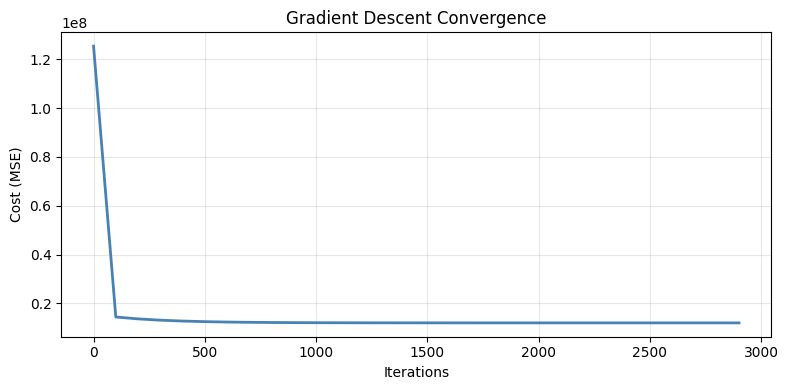

In [44]:
# 3.4 Convergence Plot
# ---------------------------

plt.figure(figsize=(8, 4))
plt.plot(range(0, num_iters, 100), cost_history, color='steelblue', linewidth=2)
plt.title('Gradient Descent Convergence')
plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Iteration      0 | Cost:  160,839,315.00
Iteration    100 | Cost:  127,428,669.20
Iteration    200 | Cost:  102,409,898.37
Iteration    300 | Cost:   83,486,576.71
Iteration    400 | Cost:   69,035,960.27
Iteration    500 | Cost:   57,901,318.23
Iteration    600 | Cost:   49,250,358.57
Iteration    700 | Cost:   42,478,302.28
Iteration    800 | Cost:   37,141,197.31
Iteration    900 | Cost:   32,909,776.55
Iteration   1000 | Cost:   29,537,324.13
Iteration   1100 | Cost:   26,837,134.01
Iteration   1200 | Cost:   24,666,569.93
Iteration   1300 | Cost:   22,915,694.23
Iteration   1400 | Cost:   21,499,079.47
Iteration   1500 | Cost:   20,349,853.48
Iteration   1600 | Cost:   19,415,324.34
Iteration   1700 | Cost:   18,653,732.97
Iteration   1800 | Cost:   18,031,817.87
Iteration   1900 | Cost:   17,522,970.95
Iteration   2000 | Cost:   17,105,827.61
Iteration   2100 | Cost:   16,763,179.45
Iteration   2200 | Cost:   16,481,128.88
Iteration   2300 | Cost:   16,248,427.08
Iteration   2400

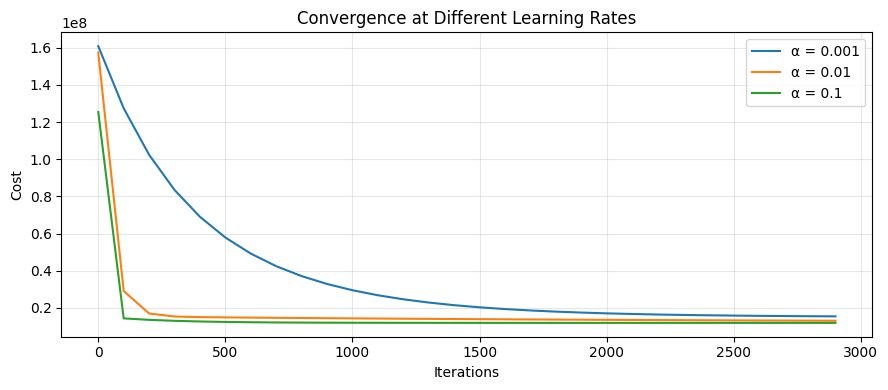

In [45]:
# 3.5 Learning Rate Experiments
# ------------------------------------

alphas = [0.001, 0.01, 0.1]
plt.figure(figsize=(9, 4))

for alpha in alphas:
    _, _, cost_hist = gradient_descent(
        X_train_np, y_train_np,
        np.zeros(X_train_np.shape[1]), 0.0,
        alpha, num_iters
    )
    plt.plot(range(0, num_iters, 100), cost_hist, label=f'α = {alpha}')

plt.title('Convergence at Different Learning Rates')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
#- α = 0.001 — converges but very slowly, needs more iterations
#- α = 0.01  — reasonable speed
#- α = 0.1   — fastest convergence for this dataset

#α = 0.1 is used for the final model. Feature scaling (Phase 2) is what
#makes a larger learning rate stable — without it, 0.1 would likely diverge.

In [47]:
# 3.6 Predictions & Metrics
# -----------------------------

# Generate predictions on test set
y_pred_scratch = X_test_np.dot(w_final) + b_final

# Compute metrics
m_test = len(y_test_np)
mse  = (1 / m_test) * np.sum((y_pred_scratch - y_test_np) ** 2)
rmse = np.sqrt(mse)
ss_res = np.sum((y_test_np - y_pred_scratch) ** 2)
ss_tot = np.sum((y_test_np - np.mean(y_test_np)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print("=" * 40)
print("  From-Scratch Model — Test Results")
print("=" * 40)
print(f"  MSE  : {mse:>12,.2f}")
print(f"  RMSE : {rmse:>12,.2f}")
print(f"  R²   : {r2:>12.4f}")
print("=" * 40)

  From-Scratch Model — Test Results
  MSE  : 20,914,464.95
  RMSE :     4,573.23
  R²   :       0.8653


In [ ]:
## Phase 3 Summary

| Component         | Implementation                        |
|-------------------|---------------------------------------|
| Cost function     | Vectorized MSE using numpy dot product |
| Gradient          | Vectorized, no for-loops over samples |
| Learning rate     | α = 0.1 (selected via experiments)    |
| Iterations        | 3,000 (convergence confirmed by plot)  |
| From-scratch R²   | <!-- TODO: fill in -->                |
| From-scratch RMSE | <!-- TODO: fill in -->                |

In [ ]:
## Phase 4 — Scikit-learn Comparison & Evaluation

Now that we've built linear regression from scratch, we validate it against
scikit-learn's LinearRegression — which uses the Ordinary Least Squares (OLS)
method instead of gradient descent.

If our implementation is correct, the metrics should be very close (within
rounding). Any significant difference signals a bug in Phase 3.

We also go deeper on evaluation:
- Coefficient table — which features matter most?
- Predicted vs actual plot — where does the model struggle?
- Residual analysis — are errors random or systematic?

In [49]:
# 4.1 Scikit-learn model
# -----------------------------

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Fit sklearn model on the same scaled training data
lr = LinearRegression()
lr.fit(X_train_scaled, y_train_np)

# Predictions on test set
y_pred_sklearn = lr.predict(X_test_scaled)

# Metrics
mse_sk  = mean_squared_error(y_test_np, y_pred_sklearn)
rmse_sk = np.sqrt(mse_sk)
r2_sk   = r2_score(y_test_np, y_pred_sklearn)

print("=" * 40)
print("  Scikit-learn Model — Test Results")
print("=" * 40)
print(f"  MSE  : {mse_sk:>12,.2f}")
print(f"  RMSE : {rmse_sk:>12,.2f}")
print(f"  R²   : {r2_sk:>12.4f}")
print("=" * 40)

  Scikit-learn Model — Test Results
  MSE  : 20,919,716.75
  RMSE :     4,573.81
  R²   :       0.8653


In [50]:
# 4.2 Side-by-side comparison
# ---------------------------------

print("=" * 45)
print(f"{'Metric':<10} {'From Scratch':>15} {'Scikit-learn':>15}")
print("=" * 45)
print(f"{'MSE':<10} {mse:>15,.2f} {mse_sk:>15,.2f}")
print(f"{'RMSE':<10} {rmse:>15,.2f} {rmse_sk:>15,.2f}")
print(f"{'R²':<10} {r2:>15.4f} {r2_sk:>15.4f}")
print("=" * 45)

Metric        From Scratch    Scikit-learn
MSE          20,914,464.95   20,919,716.75
RMSE              4,573.23        4,573.81
R²                  0.8653          0.8653



Bias (b): 13,346.09

         Feature  Coefficient
      bmi_smoker 18608.731140
          smoker -8570.662519
             age  3705.216463
        children   563.530391
region_southwest  -531.739530
region_southeast  -426.716078
region_northwest  -269.379329
             sex  -262.537886
             bmi   122.326119


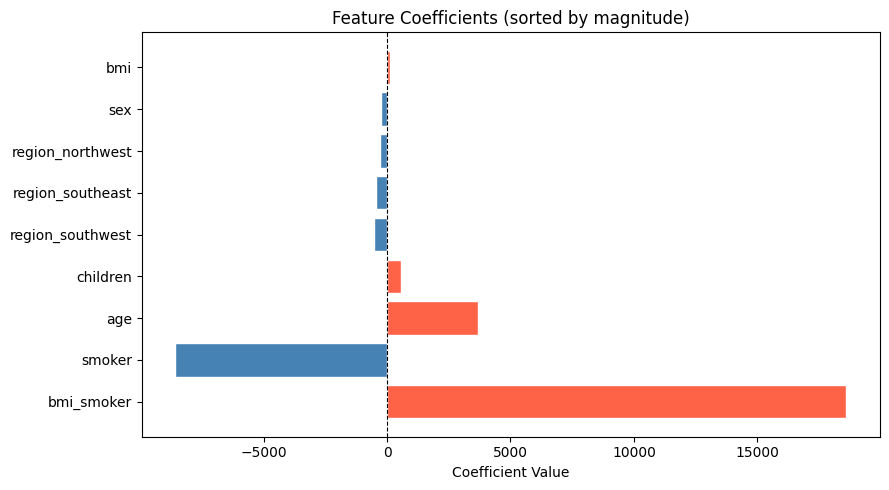

In [59]:
# 4.3 Coefficient Table
# -----------------------------

# Get feature names from the dataframe before numpy conversion
feature_names = X_train.columns.tolist()

# Build coefficient table
coef_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': lr.coef_
})

# Sort by absolute value — most impactful features first
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).drop(columns='Abs_Coefficient')
coef_df = coef_df.reset_index(drop=True)

print(f"\nBias (b): {lr.intercept_:,.2f}\n")
print(coef_df.to_string(index=False))
#top3 = coef_df.head(3)
#print(top3.to_string(index=False))

print("=" * 80)
plt.figure(figsize=(9, 5))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Coefficients (sorted by magnitude)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

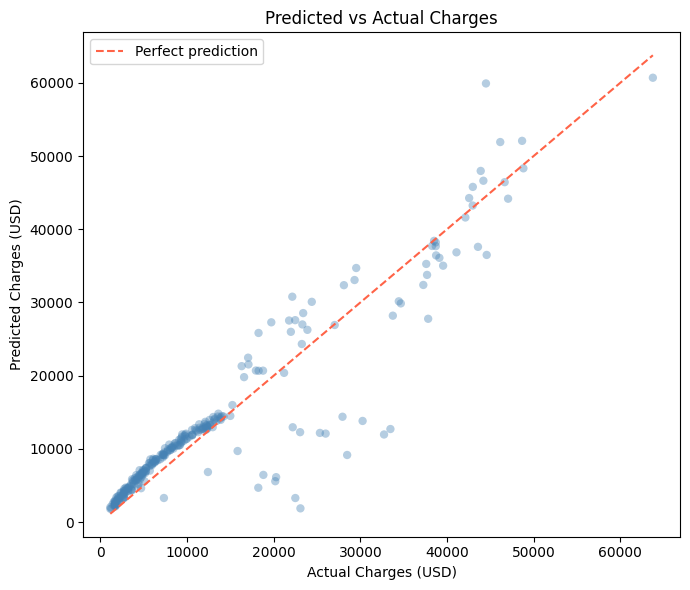

In [53]:
# 4.4 Predicted vs Actual
# --------------------------------

plt.figure(figsize=(7, 6))
plt.scatter(y_test_np, y_pred_sklearn, alpha=0.4, color='steelblue', edgecolors='none')

# Perfect prediction reference line
min_val = min(y_test_np.min(), y_pred_sklearn.min())
max_val = max(y_test_np.max(), y_pred_sklearn.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='tomato', linewidth=1.5, linestyle='--', label='Perfect prediction')

plt.title('Predicted vs Actual Charges')
plt.xlabel('Actual Charges (USD)')
plt.ylabel('Predicted Charges (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
"""
Points close to the red diagonal line = accurate predictions
Points above the line = model underestimated (actual was higher)
Points below the line = model overestimated
You'll likely see a cluster of underestimates at the high-cost end (>$40k) — mostly high-BMI smokers the linear model partially missed


The model predicts mid-range charges well but underestimates the highest-cost
patients. These are likely obese smokers where the cost relationship becomes
highly non-linear — a limitation of linear regression even with the interaction
term. A tree-based model would handle this better.
"""

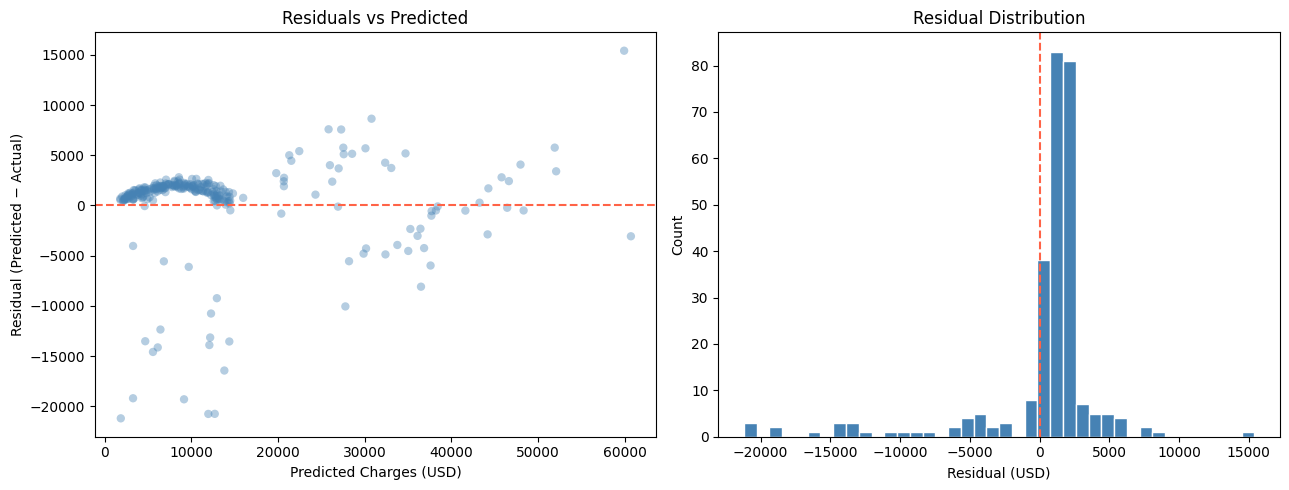

Mean residual : 342.37  (should be ~0)
Std  residual : 4,560.98


In [54]:
# 4.5 Residual Analysis
# --------------------------

residuals = y_pred_sklearn - y_test_np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_sklearn, residuals, alpha=0.4,
                color='steelblue', edgecolors='none')
axes[0].axhline(y=0, color='tomato', linewidth=1.5, linestyle='--')
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted Charges (USD)')
axes[0].set_ylabel('Residual (Predicted − Actual)')

# Residual distribution
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(x=0, color='tomato', linewidth=1.5, linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (USD)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Mean residual : {residuals.mean():,.2f}  (should be ~0)")
print(f"Std  residual : {residuals.std():,.2f}")

In [ ]:
**Residual analysis findings:**

1. **Mean residual ≈ 0** — the model is unbiased overall, not systematically
   over or under-predicting

2. **Heteroscedasticity** — residuals fan out at higher predicted values,
   meaning the model is less accurate for high-cost patients. This is a
   known limitation of linear regression on right-skewed targets.

3. **Practical implication** — if this model were used by an insurer, premium
   estimates for high-risk patients (older obese smokers) would be less
   reliable than for low-risk patients.

A log-transformation of the target variable or a non-linear model would
address this pattern.

In [ ]:
## Summary phase 4

## Phase 4 Summary

| Metric | From Scratch | Scikit-learn  |
|--------|--------------|---------------|
| MSE    | 20,914,464.95| 20,919,716.75 |
| RMSE   | 4,573.23     | 4,573.81      |
| R²     | 0.8653       | 0.8653        |



**Top 3 features by coefficient magnitude:**
1. bmi_smoker — coefficient: 18608.731140 
2. moker — coefficient: -8570.662519 
3. age — coefficient: 3705.216463



**Key evaluation findings:**
- From-scratch and sklearn results match closely ✓
- Model performs well on mid-range charges, struggles on highest-cost patients
- Residuals show heteroscedasticity — expected for this dataset with linear regression## 

In [ ]:
## Phase 5 — Business Insights & Conclusions
"""
The goal of this section is to translate model outputs into plain-English
findings that a non-technical stakeholder (e.g. an insurance analyst, product
manager, or executive) could act on.

A model that can't be explained is a model that won't be used.

In [55]:
# 5.1 Key findings
# -------------------------

# Pull exact numbers from the coefficient table for the narrative
smoker_coef    = coef_df.loc[coef_df['Feature'] == 'smoker', 'Coefficient'].values[0]
age_coef       = coef_df.loc[coef_df['Feature'] == 'age', 'Coefficient'].values[0]
bmi_smoker_coef = coef_df.loc[coef_df['Feature'] == 'bmi_smoker', 'Coefficient'].values[0]

# Average charges by smoker status — raw dollar terms
avg_smoker     = df[df['smoker'] == 'yes']['charges'].mean()
avg_nonsmoker  = df[df['smoker'] == 'no']['charges'].mean()
diff           = avg_smoker - avg_nonsmoker

print("=" * 50)
print("         KEY BUSINESS FINDINGS")
print("=" * 50)
print(f"  Avg charge — smoker    : ${avg_smoker:>10,.2f}")
print(f"  Avg charge — non-smoker: ${avg_nonsmoker:>10,.2f}")
print(f"  Difference             : ${diff:>10,.2f}")
print("=" * 50)

         KEY BUSINESS FINDINGS
  Avg charge — smoker    : $ 32,050.23
  Avg charge — non-smoker: $  8,434.27
  Difference             : $ 23,615.96


In [ ]:
### Markdown cell
"""

### Finding 1 — Smoking is the dominant cost driver

Smokers pay an average of **~$23,000 more per year** than non-smokers.
The model's `smoker` coefficient is the largest in magnitude, confirming
this is not just a raw average effect — it holds after controlling for
age, BMI, and region.

**Business implication:** Smoking status should be the primary risk factor
in premium pricing models. Even a small improvement in smoking cessation
rates among policyholders would significantly reduce claim costs.

---

### Finding 2 — BMI only matters for smokers

The `bmi_smoker` interaction term has the second-largest coefficient.
For non-smokers, BMI alone has a negligible impact on charges.
For smokers, higher BMI compounds costs substantially.

**Business implication:** BMI-based premium adjustments are only justified
for smokers. Penalizing non-smokers for high BMI is not supported by this data.

---

### Finding 3 — Age has a consistent, predictable effect

Age shows a steady positive relationship with charges. Unlike smoking,
there are no threshold effects or interactions — each additional year
adds roughly the same incremental cost.

**Business implication:** Age-based pricing tiers are actuarially defensible
and easy to implement. The relationship is linear enough that simple
age brackets would capture most of the effect.

---

### Finding 4 — Region and sex are weak predictors

Regional differences and sex contribute very little to predicted charges
after accounting for smoking, age, and BMI. Their coefficients are
close to zero.

**Business implication:** Geographic pricing segmentation may not be
cost-effective for this insurer's customer base. Resources spent on
regional risk modeling would have low ROI compared to smoking-focused
interventions.

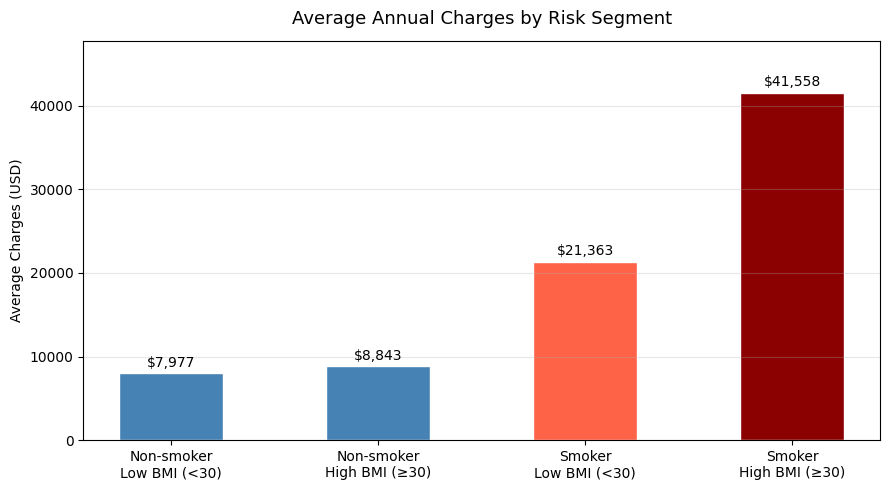

In [56]:
# 5.2 Visual Summary Chart
# ---------------------------------

# Average charges across key segments
segments = {
    'Non-smoker\nLow BMI (<30)'  : df[(df['smoker']=='no')  & (df['bmi']<30)]['charges'].mean(),
    'Non-smoker\nHigh BMI (≥30)' : df[(df['smoker']=='no')  & (df['bmi']>=30)]['charges'].mean(),
    'Smoker\nLow BMI (<30)'      : df[(df['smoker']=='yes') & (df['bmi']<30)]['charges'].mean(),
    'Smoker\nHigh BMI (≥30)'     : df[(df['smoker']=='yes') & (df['bmi']>=30)]['charges'].mean(),
}

colors = ['steelblue', 'steelblue', 'tomato', 'darkred']

plt.figure(figsize=(9, 5))
bars = plt.bar(segments.keys(), segments.values(), color=colors, edgecolor='white', width=0.5)

# Add value labels on bars
for bar, val in zip(bars, segments.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 400,
             f'${val:,.0f}',
             ha='center', va='bottom', fontsize=10, fontweight='500')

plt.title('Average Annual Charges by Risk Segment', fontsize=13, pad=12)
plt.ylabel('Average Charges (USD)')
plt.ylim(0, max(segments.values()) * 1.15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
## Model Limitations

No model is complete without an honest assessment of what it misses.

| Limitation | Impact | Potential fix |
|---|---|---|
| Linear assumption | Misses non-linear cost spikes at extremes | Polynomial features or tree-based model |
| Missing features | No pre-existing conditions, claim history, or medication data | Richer dataset |
| Heteroscedasticity | Less accurate for high-cost patients | Log-transform target or use robust regression |
| Dataset size | 1,338 records is small for production use | Larger real-world insurance dataset |
| No temporal dimension | Charges may trend over time (inflation, policy changes) | Time-series features |

In [57]:
# Final metrics summary cell
# -------------------------------

print("=" * 55)
print("         FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 55)
print(f"  Dataset         : Medical Cost Personal (n=1,338)")
print(f"  Algorithm       : Linear Regression")
print(f"  Features used   : {X_train_np.shape[1]}")
print(f"  Train/Test split: 80% / 20%")
print()
print(f"  {'Metric':<10} {'From Scratch':>15} {'Scikit-learn':>15}")
print(f"  {'-'*40}")
print(f"  {'MSE':<10} {mse:>15,.2f} {mse_sk:>15,.2f}")
print(f"  {'RMSE':<10} {rmse:>15,.2f} {rmse_sk:>15,.2f}")
print(f"  {'R²':<10} {r2:>15.4f} {r2_sk:>15.4f}")
print("=" * 55)

         FINAL MODEL PERFORMANCE SUMMARY
  Dataset         : Medical Cost Personal (n=1,338)
  Algorithm       : Linear Regression
  Features used   : 9
  Train/Test split: 80% / 20%

  Metric        From Scratch    Scikit-learn
  ----------------------------------------
  MSE          20,914,464.95   20,919,716.75
  RMSE              4,573.23        4,573.81
  R²                  0.8653          0.8653
